# FIP 12 — DA and NE at movements: onsets, instructed and uninstructed

What do DA and NE do when the animal moves, and does it matter whether the movement is the
instructed choice lick, uninstructed licking, or movement without licking?

1. DA, NE and ME around ME onsets
2. Instructed lick bouts, uninstructed lick bouts and movement without licking
3. Numbers

**Signals.** DA: dLight in lateral NAc (`latNAcc(X)-DA`). NE: GCaMP in LC noradrenergic axons
imaged in PL (`PL(X)-LCAxonCa`), i.e. axonal calcium. Both are `dff-bright_mc-iso-IRLS` dF/F at
20 Hz. The two indicators have different kinetics, so lags describe the recorded signals, not
timing in the brain.

**Movement** is motion energy (ME) from the bottom camera: the summed absolute frame-to-frame pixel
change, from the aligned ME table (`fip_motion_energy_aligned`, frame times corrected by the video
timing QC). Cameras that fail the video timing or quality screen are left out (`men_01`).

**Data.** The CSV-curated `DANE_3channels_curated` and `DANE_4channels_curated` assets. Each animal
contributes one hemisphere (the side with more sessions), with DA and NE from that side; animals
need at least 3 sessions (`fu.inventory_pairs`, `fu.choose_side`, `fu.load_pairs`). Traces sit on
one 20 Hz grid from 5 s before the first go cue to 10 s after the last; ME is averaged into the same
bins (`fu.add_motion_energy`). Each trace is z-scored over the session.

**Statistics.** Session values are averaged within animal; tests are Wilcoxon signed-rank on animal
means (smallest two-sided p with 9 animals: 0.004). Error bands are SEM over animals.

ME onsets: `fu.ME_ONSET_KW` (2.5 SD for 30 ms, one per 0.5 s) on the z-scored trace averaged onto a
100 Hz grid (`men_00`'s rate), inside the task grid.

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import fip_utils as fu
import signal_utils as su
import stats_utils as st
import behavior_utils as bu
import plot_utils as pu
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
ME_DATA_ROOT = "/root/capsule/data" if IS_CO else os.environ.get("ME_DATA_ROOT", "../../data")
PAIRS_CACHE = ("/root/capsule/scratch/fip_05/pairs.pkl" if IS_CO
               else "../../data/fip_05_cache/pairs.pkl")
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

# ── Data ─────────────────────────────────────────────────────────────────────
FS = 20.0                  # Hz, the common grid
CAMERA = "BottomCamera"
MIN_SESSIONS_PER_ANIMAL = 3
EXCLUDE_SUBJECTS = ()      # QC decides; none excluded
FS_ONSET = 100.0           # Hz, ME onsets are detected at men_00's rate

ETA_LAGS = np.arange(-2.0, 3.0 + 1e-9, 1 / FS)   # around events

# ── 2. Movement types (men_00 definitions) ───────────────────────────────────
INSTRUCTED_S = 2.0         # lick bouts starting ≤ 2 s after a go cue are instructed
LICK_WIN = (-0.5, 1.0)     # an ME event has licking if a lick falls in [onset − 0.5, onset + 1] s
PRE_WIN = (-1.0, -0.2)     # response = mean over RESP_WIN minus mean over PRE_WIN
RESP_WIN = (0.0, 1.0)

# ── Colors ───────────────────────────────────────────────────────────────────
SIG = ("da", "ne", "me")
SIG_COLOR = {"da": OKABE_ITO["vermillion"], "ne": OKABE_ITO["blue"], "me": "0.25"}
SIG_LABEL = {"da": "DA (NAc dLight)", "ne": "NE (PL LC-axon GCaMP)", "me": "ME (bottom camera)"}
OUT_COLOR = {"rewarded": OKABE_ITO["orange"], "unrewarded": "0.55"}
NULL_COLOR = PALETTE["not_sig"]
TYPE_COLOR = {"instructed, rewarded": OKABE_ITO["orange"], "instructed, unrewarded": "0.55",
              "uninstructed lick bout": OKABE_ITO["bluish_green"],
              "movement, no lick": OKABE_ITO["reddish_purple"]}

## 0. Data

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fu.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root
assert asset_roots, "no FIP asset found; check ASSET_CANDIDATES"

inv = fu.inventory_pairs(asset_roots)
kept, side_table = fu.choose_side(inv, MIN_SESSIONS_PER_ANIMAL)
all_pairs = fu.load_pairs(kept, fs=FS, cache_path=PAIRS_CACHE)
pairs = fu.add_motion_energy(all_pairs, kept, CAMERA, ME_DATA_ROOT, onset_fs=FS_ONSET,
                             exclude_subjects=EXCLUDE_SUBJECTS)

SUBJECTS = sorted({p["subject"] for p in pairs})
PAIR_SUBJECTS = [p["subject"] for p in pairs]
N_ANIMALS = len(SUBJECTS)
print(f"{len(pairs)} of {len(all_pairs)} sessions have bottom-camera ME; {N_ANIMALS} animals")
pd.Series(PAIR_SUBJECTS).value_counts().sort_index().rename("sessions").to_frame().T

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data


loaded 97 pairs from cache ../../data/fip_05_cache/pairs.pkl


88 of 97 sessions have bottom-camera ME; 9 animals


,800886,808054,809487,809491,815334,816212,816214,818585,818586
sessions,4,15,8,19,3,5,5,7,22


In [4]:
def animal_traces(per_session):
    # [(subject, trace)] -> (n_animals, n_lags): session traces averaged within animal
    if not per_session:
        return np.empty((0, len(ETA_LAGS)))
    subj, traces = zip(*per_session)
    return st.group_means(traces, subj)[1]


def report(title, df, cols):
    # mean ± SEM over animals and Wilcoxon p against zero, one row per column of an animal table
    rows = []
    for c in cols:
        m, p, n = st.wilcoxon_animals(df[c])
        rows.append(dict(measure=c, mean=m, sem=df[c].std(ddof=1) / np.sqrt(df[c].notna().sum()),
                         p=p, n=n))
    print(f"── {title}")
    print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3g}"))
    print()

## 1. DA, NE and ME around ME onsets

Each signal averaged around every ME onset in the session, session averages averaged within animal.

In [5]:
eta_onset = {s: [] for s in SIG}
rows = []
for p in pairs:
    on = p["me_onsets"]
    for s in SIG:
        eta_onset[s].append((p["subject"], np.nanmean(su.peri_event_grid(p["z"][s], p["t0"], FS, on, ETA_LAGS), 0)))
    rows.append(dict(subject=p["subject"], session=p["session"],
                     onsets_per_min=len(on) / (len(p["z"]["me"]) / FS / 60)))
onset_sess = pd.DataFrame(rows)
onset_animal = st.animal_means(onset_sess, ["onsets_per_min"], by_session=False)
report("ME onsets per minute", onset_animal, ["onsets_per_min"])
for s in SIG:
    m = animal_traces(eta_onset[s]).mean(0)
    k = int(np.argmax(m))
    print(f"{s.upper()}: peak of the mean over animals {m[k]:.2f} z at {ETA_LAGS[k]:+.2f} s")

── ME onsets per minute
       measure  mean   sem       p  n
onsets_per_min  5.09 0.876 0.00391  9

DA: peak of the mean over animals 0.47 z at +0.00 s
NE: peak of the mean over animals 1.42 z at +0.15 s
ME: peak of the mean over animals 2.67 z at +0.00 s


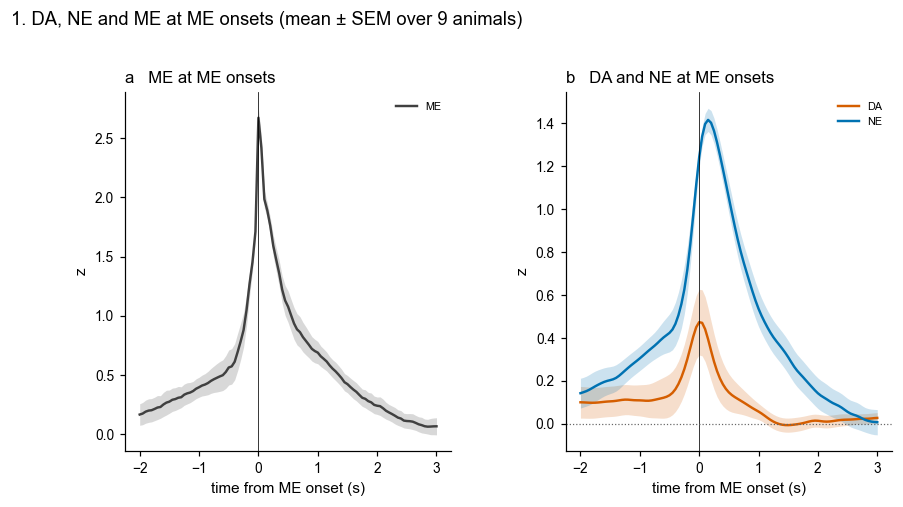

In [6]:
fig = plt.figure(figsize=(9, 4.6))
gs = GridSpec(1, 2, figure=fig, wspace=0.35, top=0.82)
ax = fig.add_subplot(gs[0])
pu.plot_mean_sem(ax, ETA_LAGS, animal_traces(eta_onset["me"]), SIG_COLOR["me"], "ME")
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("time from ME onset (s)")
ax.set_ylabel("z")
ax.set_title("a   ME at ME onsets", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[1])
for s in ("da", "ne"):
    pu.plot_mean_sem(ax, ETA_LAGS, animal_traces(eta_onset[s]), SIG_COLOR[s], s.upper())
ax.axvline(0, color="k", lw=0.5)
ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
ax.set_xlabel("time from ME onset (s)")
ax.set_ylabel("z")
ax.set_title("b   DA and NE at ME onsets", loc="left")
ax.legend(fontsize=7)
style_ax(ax)
fig.suptitle(f"1. DA, NE and ME at ME onsets (mean ± SEM over {N_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_12_1_me_onsets", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 2. Instructed and uninstructed movement

Four kinds of movement onset, with `men_00`'s definitions:

- **instructed lick bouts**, starting ≤ 2 s after a go cue, split by that trial's outcome (the
  bout's first lick is the choice, so the rewarded ones carry the reward response);
- **uninstructed lick bouts**, starting more than 2 s after the latest go cue (library
  `annotate_lick_bouts`, 0.7 s gap);
- **movement without licking**: ME onsets with no lick from 0.5 s before to 1 s after, outside
  task events (`bu.label_context` "quiet": not within 1.5 s after an outcome or an ignored cue).

Response: mean 0–1 s after onset minus mean −1 to −0.2 s.

In [7]:
TYPES = list(TYPE_COLOR)
eta_type = {(k, s): [] for k in TYPES for s in SIG}
rows = []
for p in pairs:
    tr = p["trials"]
    cues = tr["goCue_start_time_in_session"].to_numpy()
    rewarded = (tr["earned_reward"].fillna(0).astype(bool) & (tr["animal_response"] < 2)).to_numpy()
    span = (np.nanmin(cues), np.nanmax(cues) + 10.0)
    le = p["lick_events"]
    bouts = bu.lick_bouts(le[(le.timestamps >= span[0]) & (le.timestamps < span[1])])
    instr, uninstr = bu.classify_bout_times(bouts["onset"], cues[np.isfinite(cues)],
                                            go_response_window_s=INSTRUCTED_S,
                                            iti_min_post_cue_s=INSTRUCTED_S, iti_min_pre_next_s=0.0)
    order = np.argsort(cues)
    k = order[np.searchsorted(cues[order], instr, side="right") - 1]   # trial of each instructed bout
    ev = p["me_onsets"]
    ev = ev[(ev >= span[0]) & (ev < span[1])]
    ev = ev[~su.near_any(ev, p["licks"], *LICK_WIN)]
    ev = ev[bu.label_context(ev, tr, p["licks"]) == "quiet"]
    onsets = {"instructed, rewarded": instr[rewarded[k]], "instructed, unrewarded": instr[~rewarded[k]],
              "uninstructed lick bout": uninstr, "movement, no lick": ev}
    r = dict(subject=p["subject"], session=p["session"])
    for typ, t in onsets.items():
        r[f"n {typ}"] = len(t)
        if len(t) < 3:
            continue
        for s in SIG:
            x = p["z"][s]
            eta_type[(typ, s)].append((p["subject"], np.nanmean(su.peri_event_grid(x, p["t0"], FS, t, ETA_LAGS), 0)))
            resp = (su.window_mean_grid(x, p["t0"], FS, t, *RESP_WIN)
                    - su.window_mean_grid(x, p["t0"], FS, t, *PRE_WIN))
            r[f"{s}: {typ}"] = np.nanmean(resp)
    rows.append(r)
type_sess = pd.DataFrame(rows)
type_animal = st.animal_means(type_sess, [c for c in type_sess if c not in ("subject", "session")],
                              by_session=False)
print("events per session (mean over animals):")
print(type_animal[[f"n {t}" for t in TYPES]].mean().round(1).to_string())
print()
report("responses (z, 0–1 s minus −1 to −0.2 s)", type_animal, [f"{s}: {t}" for s in SIG for t in TYPES])
for s in ("da", "ne"):
    type_animal[f"{s}: uninstructed − instructed unrewarded"] = (
        type_animal[f"{s}: uninstructed lick bout"] - type_animal[f"{s}: instructed, unrewarded"])
    type_animal[f"{s}: no-lick movement − uninstructed bout"] = (
        type_animal[f"{s}: movement, no lick"] - type_animal[f"{s}: uninstructed lick bout"])
report("paired differences", type_animal,
       [f"{s}: {d}" for s in ("da", "ne")
        for d in ("uninstructed − instructed unrewarded", "no-lick movement − uninstructed bout")])

events per session (mean over animals):
n instructed, rewarded      223.1
n instructed, unrewarded    255.3
n uninstructed lick bout    211.6
n movement, no lick         102.7

── responses (z, 0–1 s minus −1 to −0.2 s)
                   measure    mean    sem       p  n
  da: instructed, rewarded       2  0.121 0.00391  9
da: instructed, unrewarded   0.315 0.0927  0.0117  9
da: uninstructed lick bout -0.0466 0.0565    0.57  9
     da: movement, no lick  0.0822 0.0296  0.0391  9
  ne: instructed, rewarded    1.27 0.0926 0.00391  9
ne: instructed, unrewarded   0.911  0.104 0.00391  9
ne: uninstructed lick bout   0.563 0.0643 0.00391  9
     ne: movement, no lick   0.525  0.113 0.00781  9
  me: instructed, rewarded    1.63  0.123 0.00391  9
me: instructed, unrewarded    1.01  0.173 0.00391  9
me: uninstructed lick bout   0.563  0.066 0.00391  9
     me: movement, no lick   0.469 0.0988 0.00391  9

── paired differences
                                 measure    mean    sem       p  n
d

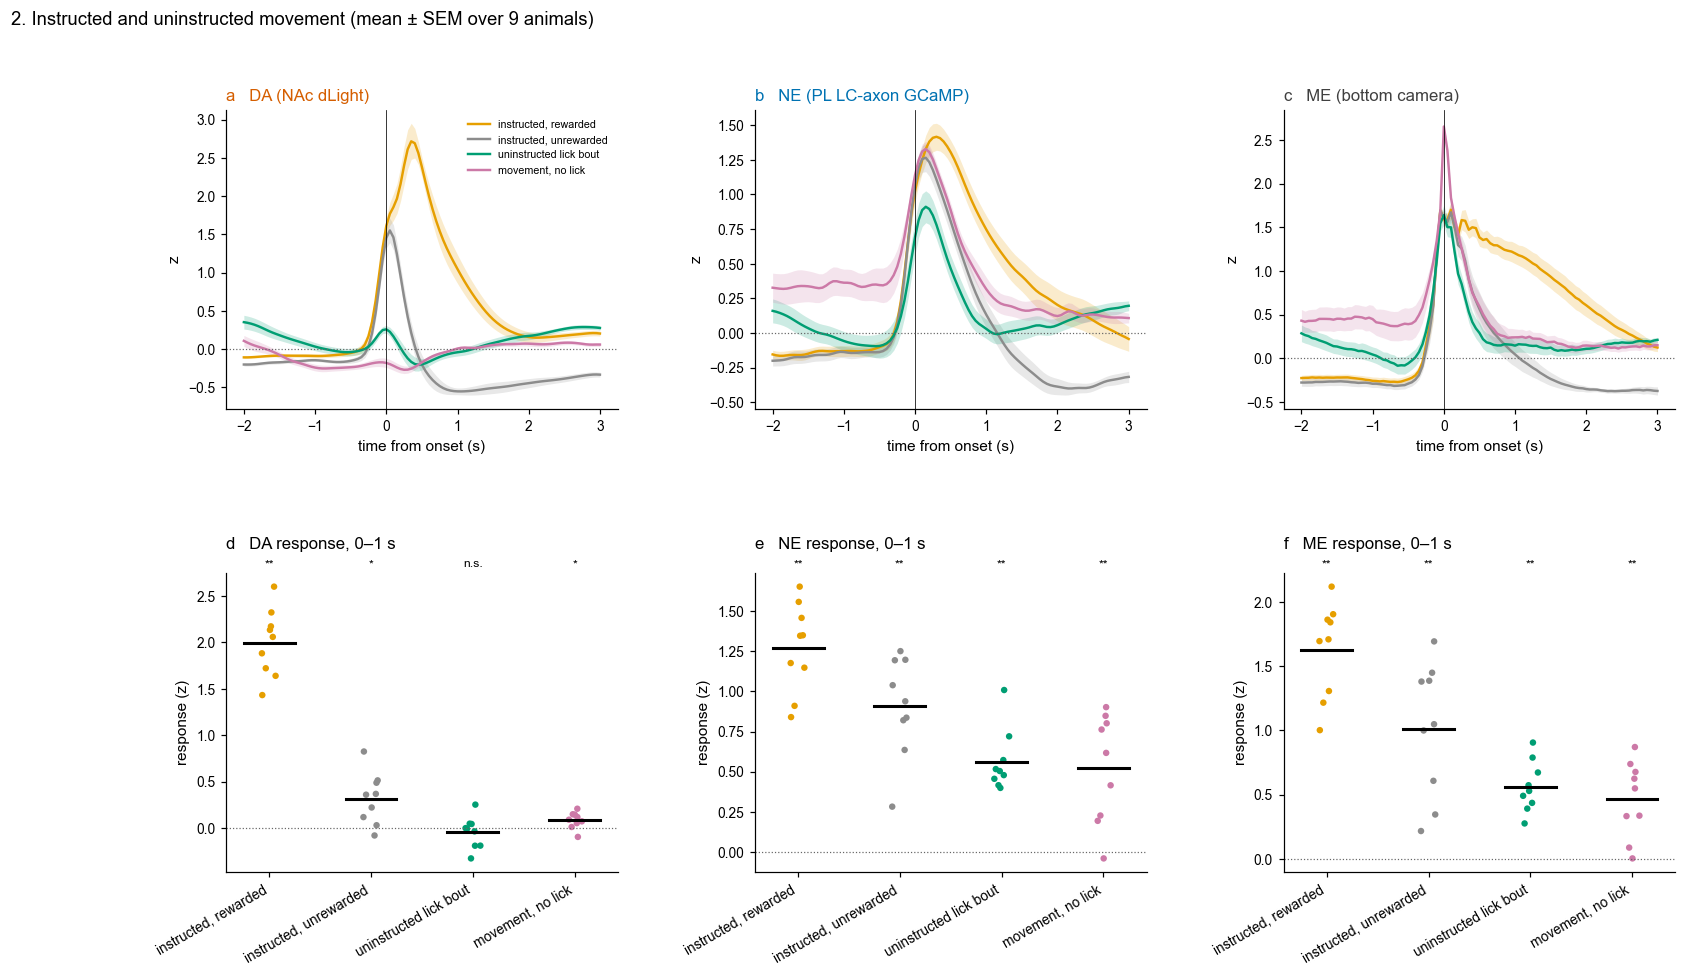

In [8]:
fig = plt.figure(figsize=(17, 9))
gs = GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.35, top=0.88)
for j, s in enumerate(SIG):
    ax = fig.add_subplot(gs[0, j])
    for typ in TYPES:
        pu.plot_mean_sem(ax, ETA_LAGS, animal_traces(eta_type[(typ, s)]), TYPE_COLOR[typ], typ)
    ax.axvline(0, color="k", lw=0.5)
    ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
    ax.set_xlabel("time from onset (s)")
    ax.set_ylabel("z")
    ax.set_title(f"{'abc'[j]}   {SIG_LABEL[s]}", loc="left", color=SIG_COLOR[s])
    if j == 0:
        ax.legend(fontsize=7)
    style_ax(ax)
    ax = fig.add_subplot(gs[1, j])
    pu.strip_by_measure(ax, type_animal, [f"{s}: {t}" for t in TYPES], TYPES,
                        [TYPE_COLOR[t] for t in TYPES], "response (z)",
                        title=f"{'def'[j]}   {s.upper()} response, 0–1 s", connect=False)
fig.suptitle(f"2. Instructed and uninstructed movement (mean ± SEM over {N_ANIMALS} animals)",
             x=0.01, ha="left")
save_fig(fig, "fip_12_2_movement_types", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 3. Numbers

One row per measure: mean over animals, Wilcoxon p against zero, animals positive.

In [9]:
def row(section, measure, df, col):
    # one measure of an animal table: mean, Wilcoxon p against 0, animals positive
    v = df[col]
    m, p, n = st.wilcoxon_animals(v)
    return dict(section=section, measure=measure, mean=round(m, 3), p=round(p, 4),
                animals_positive=f"{int((v > 0).sum())}/{n}")


S = [row("1", "ME onsets per minute", onset_animal, "onsets_per_min")]
S += [row("2", f"{s.upper()} {t}", type_animal, f"{s}: {t}") for s in SIG for t in TYPES]
S += [row("2", c, type_animal, c) for c in type_animal if " − " in c]
pd.DataFrame(S).set_index(["section", "measure"])

mean       p animals_positive
section measure                                                                 
1       ME onsets per minute                      5.091  0.0039              9/9
2       DA instructed, rewarded                   1.996  0.0039              9/9
        DA instructed, unrewarded                 0.315  0.0117              8/9
        DA uninstructed lick bout                -0.047  0.5703              3/9
        DA movement, no lick                      0.082  0.0391              8/9
        NE instructed, rewarded                   1.272  0.0039              9/9
        NE instructed, unrewarded                 0.911  0.0039              9/9
        NE uninstructed lick bout                 0.563  0.0039              9/9
        NE movement, no lick                      0.525  0.0078              8/9
        ME instructed, rewarded                   1.627  0.0039              9/9
        ME instructed, unrewarded                 1.014  0.0039              9/9
        ME uninstructed lick bout                 0.563  0.0039              9/9
        ME movement, no lick                      0.469  0.0039              9/9
        da: uninstructed − instructed unrewarded -0.361  0.0039              0/9
        da: no-lick movement − uninstructed bout  0.129  0.0742              7/9
        ne: uninstructed − instructed unrewarded -0.348  0.0117              1/9
        ne: no-lick movement − uninstructed bout -0.038  0.7344              4/9